<h1 align="center">3. Análise de Vulnerabilidade (Métricas de Centralidade e Identificação dos Nós Críticos)</h1>

In [2]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / 'src'))
from notebook_setup import *

gtfs = carregar_gtfs()
stop_times, trips, routes, stops = gtfs['stop_times'], gtfs['trips'], gtfs['routes'], gtfs['stops']
G_principal, stops_com_modal = carregar_artefatos()

print(f"✓ G_principal: {G_principal.number_of_nodes():,} nós, {G_principal.number_of_edges():,} arestas")

✓ G_principal: 22,099 nós, 32,163 arestas


In [3]:
# CORREÇÃO DOS MODAIS
# Mapear cada stop_id ao conjunto de route_types que o servem.
# Para stop_ids servidos por mais de um modal, gera label combinada

stop_modais = (
    stop_times[['stop_id', 'trip_id']].drop_duplicates()
    .merge(trips[['trip_id', 'route_id']], on='trip_id')
    .merge(routes[['route_id', 'route_type']], on='route_id')
    .groupby('stop_id')['route_type']
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)

def modais_para_label(modais):
    nomes = {1: 'Metrô', 2: 'CPTM', 3: 'Ônibus'}
    if not modais:
        return None
    return ' + '.join(nomes[m] for m in sorted(modais))

stop_modais['modal_label'] = stop_modais['route_type'].apply(modais_para_label)

print(f"✓ stop_modais: {len(stop_modais):,} linhas")
print(f"\nDistribuição de modal_label:")
print(stop_modais['modal_label'].value_counts())

✓ stop_modais: 22,101 linhas

Distribuição de modal_label:
modal_label
Ônibus    21903
CPTM        104
Metrô        94
Name: count, dtype: int64


In [4]:
# Verificar se há estações com mesmo nome mas stop_ids distintos

# Esperado: estações como Brás, Luz, Tatuapé aparecerem com 2+ stop_ids, cada um servido por um modal diferente.

print("=== Estações Metrô/CPTM que aparecem com mesmo nome em mais de um stop_id ===\n")

estacoes_homonimas = (
    stops_com_modal[stops_com_modal['route_type'].isin([1, 2])]
    .groupby('stop_name')
    .agg(
        n_stop_ids=('stop_id', 'nunique'),
        modais=('route_type', lambda x: sorted(set(x))),
    )
    .reset_index()
    .query('n_stop_ids > 1')
    .sort_values('n_stop_ids', ascending=False)
)

print(f"Total de nomes repetidos: {len(estacoes_homonimas)}")
print(estacoes_homonimas.head(20).to_string(index=False))

=== Estações Metrô/CPTM que aparecem com mesmo nome em mais de um stop_id ===

Total de nomes repetidos: 16
              stop_name  n_stop_ids modais
                    Luz           4 [1, 2]
                   Brás           3 [1, 2]
Palmeiras - Barra Funda           3 [1, 2]
                Tatuapé           3 [1, 2]
               Ana Rosa           2    [1]
           Calmon Viana           2    [2]
         Chácara Klabin           2    [1]
   Corinthians-itaquera           2 [1, 2]
           Eng. Goulart           2    [2]
                Paraíso           2    [1]
      Presidente Altino           2    [2]
              República           2    [1]
             Santa Cruz           2    [1]
            Santo Amaro           2 [1, 2]
                     Sé           2    [1]
            Tamanduateí           2 [1, 2]


<h2>3.1 Métricas de Centralidade</h2>

In [5]:
# 1. DEGREE CENTRALITY
print("1/3 Degree centrality...")
degree_cent = nx.degree_centrality(G_principal)

# 2. BETWEENNESS CENTRALITY
print("2/3 Betweenness centrality (k=500)...")
betweenness_cent = nx.betweenness_centrality(G_principal, k=500, seed=42)

# 3. CLOSENESS CENTRALITY
print("3/3 Closeness centrality...")
closeness_cent = nx.closeness_centrality(G_principal)

1/3 Degree centrality...
2/3 Betweenness centrality (k=500)...
3/3 Closeness centrality...


In [6]:
# Montar DataFrame consolidado com centralidades + atributos

df_centralidades = pd.DataFrame({
    'stop_id': list(G_principal.nodes()),
    'degree': [G_principal.degree(n) for n in G_principal.nodes()],
    'degree_centrality': [degree_cent[n] for n in G_principal.nodes()],
    'betweenness_centrality': [betweenness_cent[n] for n in G_principal.nodes()],
    'closeness_centrality': [closeness_cent[n] for n in G_principal.nodes()],
})

# Adicionar nome, lat, lon a partir dos atributos do grafo
df_centralidades['stop_name'] = df_centralidades['stop_id'].map(
    lambda n: G_principal.nodes[n].get('name', '')
)
df_centralidades['lat'] = df_centralidades['stop_id'].map(
    lambda n: G_principal.nodes[n].get('lat', np.nan)
)
df_centralidades['lon'] = df_centralidades['stop_id'].map(
    lambda n: G_principal.nodes[n].get('lon', np.nan)
)

# Adicionar modal_label (vindo da Célula 2)
df_centralidades = df_centralidades.merge(
    stop_modais[['stop_id', 'modal_label']],
    on='stop_id', how='left'
)

print(f"✓ df_centralidades: {len(df_centralidades):,} linhas, {len(df_centralidades.columns)} colunas")
print(f"\nColunas: {df_centralidades.columns.tolist()}")
print(f"\nEstatísticas:")
print(df_centralidades[['degree', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality']].describe())

✓ df_centralidades: 22,099 linhas, 9 colunas

Colunas: ['stop_id', 'degree', 'degree_centrality', 'betweenness_centrality', 'closeness_centrality', 'stop_name', 'lat', 'lon', 'modal_label']

Estatísticas:
             degree  degree_centrality  betweenness_centrality  \
count  22099.000000       22099.000000            22099.000000   
mean       2.910810           0.000132                0.001437   
std        2.328362           0.000105                0.009120   
min        1.000000           0.000045                0.000000   
25%        2.000000           0.000091                0.000040   
50%        2.000000           0.000091                0.000140   
75%        3.000000           0.000136                0.000542   
max       63.000000           0.002851                0.380227   

       closeness_centrality  
count          22099.000000  
mean               0.032519  
std                0.007057  
min                0.011994  
25%                0.027528  
50%                0

In [7]:
# Top 10 paradas para cada métrica de centralidade

cols_exibir = ['stop_name', 'modal_label', 'degree', 'betweenness_centrality', 'closeness_centrality']

for metrica in ['degree', 'betweenness_centrality', 'closeness_centrality']:
    print("=" * 70)
    print(f"  TOP 10 — {metrica.upper()}")
    print("=" * 70)
    print(
        df_centralidades.nlargest(10, metrica)[cols_exibir].to_string(index=True)
    )
    print()

  TOP 10 — DEGREE
                  stop_name modal_label  degree  betweenness_centrality  closeness_centrality
16938               Santana       Metrô      63                0.114060              0.043573
160    Corinthians-itaquera        CPTM      61                0.203033              0.049659
14726           Largo Treze       Metrô      61                0.035304              0.037776
10831  Corinthians-itaquera       Metrô      60                0.021092              0.045741
3267         Lapa (linha 8)        CPTM      59                0.142682              0.047906
5639                 Grajaú        CPTM      46                0.104129              0.033101
13899              Pirituba        CPTM      46                0.106190              0.043557
14076            Anhangabaú       Metrô      46                0.006701              0.049840
2543             São Mateus       Metrô      45                0.044280              0.034083
566      Av. Pe. José Maria      Ônibus   

In [8]:
# Investigar a estação Brás
bras_ids = stops_com_modal[stops_com_modal['stop_name'] == 'Brás']
print("Stop_ids da Brás:")
print(bras_ids[['stop_id', 'stop_name', 'route_type', 'stop_lat', 'stop_lon']].to_string(index=False))

# Distância entre os stop_ids da Brás
from itertools import combinations
import math

def haversine_metros(lat1, lon1, lat2, lon2):
    R = 6_371_000
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dl/2)**2
    return 2 * R * math.asin(math.sqrt(a))

print("\nDistâncias entre os stop_ids da Brás:")
ids = bras_ids[['stop_id', 'stop_lat', 'stop_lon']].dropna().to_dict('records')
for a, b in combinations(ids, 2):
    d = haversine_metros(a['stop_lat'], a['stop_lon'], b['stop_lat'], b['stop_lon'])
    print(f"  {a['stop_id']} ↔ {b['stop_id']}: {d:.0f}m")

# Grau no grafo
print("\nGraus dos stop_ids da Brás no G_principal:")
for sid in bras_ids['stop_id']:
    if sid in G_principal:
        print(f"  stop_id {sid}: grau {G_principal.degree(sid)}")
    else:
        print(f"  stop_id {sid}: não está no G_principal")

Stop_ids da Brás:
 stop_id stop_name  route_type   stop_lat   stop_lon
   18987      Brás           2 -23.545461 -46.616228
 1010053      Brás           2 -23.545582 -46.616314
 1010054      Brás           1 -23.547751 -46.616127

Distâncias entre os stop_ids da Brás:
  18987 ↔ 1010053: 16m
  18987 ↔ 1010054: 255m
  1010053 ↔ 1010054: 242m

Graus dos stop_ids da Brás no G_principal:
  stop_id 18987: grau 7
  stop_id 1010053: grau 5
  stop_id 1010054: grau 5


In [9]:
# Sobreposição entre os top-10 das três métricas

top10_degree = set(df_centralidades.nlargest(10, 'degree')['stop_id'])
top10_between = set(df_centralidades.nlargest(10, 'betweenness_centrality')['stop_id'])
top10_close = set(df_centralidades.nlargest(10, 'closeness_centrality')['stop_id'])

print("SOBREPOSIÇÃO ENTRE RANKINGS")
print(f"  Degree ∩ Betweenness:        {len(top10_degree & top10_between)} de 10")
print(f"  Degree ∩ Closeness:          {len(top10_degree & top10_close)} de 10")
print(f"  Betweenness ∩ Closeness:     {len(top10_between & top10_close)} de 10")
print(f"  Nos 3 rankings simultâneos:  {len(top10_degree & top10_between & top10_close)} de 10")

SOBREPOSIÇÃO ENTRE RANKINGS
  Degree ∩ Betweenness:        1 de 10
  Degree ∩ Closeness:          0 de 10
  Betweenness ∩ Closeness:     2 de 10
  Nos 3 rankings simultâneos:  0 de 10


In [10]:
# Salvar para uso posterior

df_centralidades.to_parquet(DATA_PROCESSED / 'centralidades.parquet')
print(f"✓ Salvo: {len(df_centralidades):,} linhas")
print(f"  Caminho: {DATA_PROCESSED / 'centralidades.parquet'}")

✓ Salvo: 22,099 linhas
  Caminho: /Users/cintiashinoda/Desktop/public-transit-graph-theory/public-transit-graph-theory-repo/data/processed/centralidades.parquet


Stop_ids em múltiplos rankings: 3


/var/folders/hf/dw8vz6md6xb35m96f3tykr6m0000gn/T/ipykernel_12752/2249402173.py:102: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  sp_centroid = sp_cidade.geometry.centroid.iloc[0]


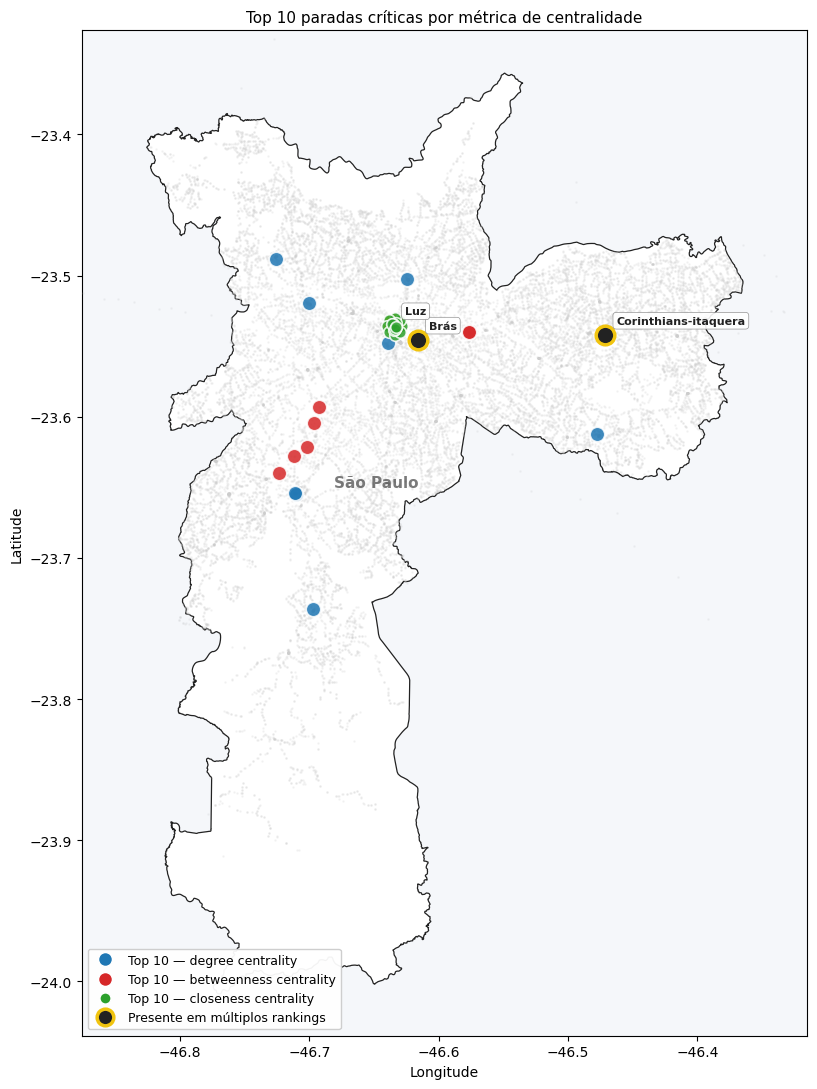


✓ Salvo em: outputs/mapa_top10_centralidades.png


In [16]:
# Mapa: top-10 paradas críticas por métrica de centralidade

import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- 1. Extrair top-10 de cada métrica ---
top10_degree = df_centralidades.nlargest(10, 'degree')
top10_between = df_centralidades.nlargest(10, 'betweenness_centrality')
top10_close = df_centralidades.nlargest(10, 'closeness_centrality')

# Stop_ids em múltiplos rankings (tratamento visual especial)
ids_degree = set(top10_degree['stop_id'])
ids_between = set(top10_between['stop_id'])
ids_close = set(top10_close['stop_id'])
ids_compartilhados = (
    (ids_degree & ids_between) | (ids_degree & ids_close) | (ids_between & ids_close)
)
print(f"Stop_ids em múltiplos rankings: {len(ids_compartilhados)}")

# --- 2. Carregar shapefile do município de SP ---
municipios = gpd.read_file(REPO_ROOT / 'data' / 'raw' / 'ibge' / 'SP_Municipios_2024.shp')
if municipios.crs.to_string() != 'EPSG:4326':
    municipios = municipios.to_crs('EPSG:4326')

sp_cidade = municipios[municipios['NM_MUN'] == 'São Paulo']
bounds = sp_cidade.total_bounds

# --- 3. Plotar base do mapa ---
fig, ax = plt.subplots(figsize=(11, 11))
ax.set_facecolor('#f5f7fa')

# Camada base: município de SP
sp_cidade.plot(ax=ax, facecolor='#ffffff', edgecolor='#222222', linewidth=0.9, zorder=2)

# Camada de paradas (todas em cinza muito claro, como referência de fundo)
ax.scatter(
    df_centralidades['lon'], df_centralidades['lat'],
    s=1, alpha=0.15, color='#cccccc', zorder=3,
)

# --- 4. Top-10 de cada métrica ---
cores = {
    'degree': '#1f77b4',
    'betweenness': '#d62728',
    'closeness': '#2ca02c',
}


# Posição central do aglomerado closeness
close_lon_center = top10_close[~top10_close['stop_id'].isin(ids_compartilhados)]['lon'].mean()
close_lat_center = top10_close[~top10_close['stop_id'].isin(ids_compartilhados)]['lat'].mean()

# Espalhar visualmente num círculo de ~600m de raio (sem mover dados reais)
close_filtered = top10_close[~top10_close['stop_id'].isin(ids_compartilhados)]
n = len(close_filtered)
angulos = np.linspace(0, 2 * np.pi, n, endpoint=False)
raio_visual = 0.006  # ~0,006° ≈ 600m

ax.scatter(
    close_lon_center + raio_visual * np.cos(angulos),
    close_lat_center + raio_visual * np.sin(angulos),
    s=70, alpha=0.85, color=cores['closeness'],
    edgecolors='white', linewidths=1.2,
    zorder=7,
)

# Ordem de plotagem: degree → betweenness → closeness (closeness por cima)
plotar_pontos(top10_degree, cores['degree'], size=110, zorder=4, exclude_shared=True)
plotar_pontos(top10_between, cores['betweenness'], size=110, zorder=5, exclude_shared=True)
plotar_pontos(top10_close, cores['closeness'], size=70, zorder=7, exclude_shared=True)
# closeness com tamanho menor (70) e zorder maior (7) — aparece por cima sem cobrir os outros

# --- 5. Pontos em múltiplos rankings: marcador preto com borda amarela ---
for stop_id in ids_compartilhados:
    row = df_centralidades[df_centralidades['stop_id'] == stop_id].iloc[0]
    ax.scatter(
        row['lon'], row['lat'],
        s=180, color='#222222',
        edgecolors='#f1c40f', linewidths=2.5,
        zorder=6,
    )
    ax.annotate(
        row['stop_name'],
        xy=(row['lon'], row['lat']),
        xytext=(8, 8), textcoords='offset points',
        fontsize=8, fontweight='bold',
        color='#222222',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor='#888', alpha=0.9, linewidth=0.5),
        zorder=8,
    )

# --- 6. Limites do mapa ---
margem_horizontal = 0.05
margem_vertical = 0.03
ax.set_xlim(bounds[0] - margem_horizontal, bounds[2] + margem_horizontal)
ax.set_ylim(bounds[1] - margem_vertical, bounds[3] + margem_vertical)

# --- 7. Anotação "São Paulo" no centróide ---
sp_centroid = sp_cidade.geometry.centroid.iloc[0]
ax.annotate(
    'São Paulo',
    xy=(sp_centroid.x, sp_centroid.y),
    fontsize=11, fontweight='bold',
    color='#222222', alpha=0.6, ha='center',
)

# --- 8. Legenda customizada ---
handles_legenda = [
    Line2D([0], [0], marker='o', color='none', markerfacecolor=cores['degree'],
           markeredgecolor='white', markersize=10, label='Top 10 — degree centrality'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=cores['betweenness'],
           markeredgecolor='white', markersize=10, label='Top 10 — betweenness centrality'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor=cores['closeness'],
           markeredgecolor='white', markersize=8, label='Top 10 — closeness centrality'),
    Line2D([0], [0], marker='o', color='none', markerfacecolor='#222222',
           markeredgecolor='#f1c40f', markersize=12, markeredgewidth=2.5,
           label='Presente em múltiplos rankings'),
]
ax.legend(handles=handles_legenda, loc='lower left', fontsize=9, framealpha=0.95)

# # --- 9. Nota explicativa sobre a concentração do closeness ---
# ax.text(
#     0.02, 0.17,
#     'Nota: 9 das 10 paradas de maior closeness centrality\n'
#     'localizam-se no entorno da Estação da Luz, formando\n'
#     'um aglomerado de ~300m de raio.',
#     transform=ax.transAxes,
#     fontsize=8, color='#444', style='italic',
#     bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
#               edgecolor='#aaa', alpha=0.85),
#     verticalalignment='bottom',
# )

# --- 10. Título e eixos ---
ax.set_title(
    'Top 10 paradas críticas por métrica de centralidade',
    fontsize=11,
)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# --- 11. Salvar e exibir ---
plt.tight_layout()
plt.savefig(
    str(REPO_ROOT / 'outputs' / 'mapa_top10_centralidades.png'),
    dpi=200, bbox_inches='tight'
)
plt.show()
print("\n✓ Salvo em: outputs/mapa_top10_centralidades.png")

In [19]:
# Ranquear em cada métrica (1 = mais importante)
metricas['rank_degree'] = metricas['degree'].rank(ascending=False)
metricas['rank_betweenness'] = metricas['betweenness_centrality'].rank(ascending=False)
metricas['rank_closeness'] = metricas['closeness_centrality'].rank(ascending=False)

# Ranking combinado = média dos 3
metricas['rank_combinado'] = (
    metricas['rank_degree'] + metricas['rank_betweenness'] + metricas['rank_closeness']
) / 3

# Top 20 mais críticos
print("TOP 20 — NÓS MAIS CRÍTICOS (ranking combinado)")
print("=" * 80)
top_criticos = metricas.nsmallest(20, 'rank_combinado')[
    ['stop_name', 'modal', 'degree', 'betweenness_centrality',
     'closeness_centrality', 'rank_combinado']
]
top_criticos.index = range(1, 21)
print(top_criticos.to_string())

print(f"\nDistribuição por modal nos top 20 mais críticos:")
print(top_criticos['modal'].value_counts())

NameError: name 'metricas' is not defined

In [ ]:
from networkx.algorithms.community import louvain_communities, modularity

print("Detectando comunidades com Louvain...")
comunidades = louvain_communities(G_principal, seed=42)

Q = modularity(G_principal, comunidades)
print(f"\nComunidades encontradas: {len(comunidades)}")
print(f"Modularidade (Q):       {Q:.4f}")
print(f"  (Q próximo de 1 = comunidades bem definidas)")

# Atribuir comunidade a cada nó
comunidades_ord = sorted(comunidades, key=len, reverse=True)
node_to_community = {}
for i, com in enumerate(comunidades_ord):
    for node in com:
        node_to_community[node] = i

metricas['comunidade'] = metricas['stop_id'].map(node_to_community)

print(f"\nTamanho das top 15 comunidades:")
for i, com in enumerate(comunidades_ord[:15]):
    pct = len(com) / G_principal.number_of_nodes() * 100
    print(f"  Comunidade {i+1}: {len(com):>5,} nós ({pct:>5.1f}%)")

if len(comunidades_ord) > 15:
    resto = sum(len(c) for c in comunidades_ord[15:])
    print(f"  + {len(comunidades_ord) - 15} comunidades menores: {resto:,} nós")

In [ ]:
fig, ax = plt.subplots(figsize=(12, 12))

n_top = min(20, len(comunidades_ord))
cmap = plt.cm.get_cmap('tab20', n_top)

for i, com in enumerate(comunidades_ord[:n_top]):
    lats = [G_principal.nodes[n].get('lat', np.nan) for n in com]
    lons = [G_principal.nodes[n].get('lon', np.nan) for n in com]
    ax.scatter(lons, lats, s=1, c=[cmap(i)], alpha=0.6,
               label=f'Com. {i+1} ({len(com):,})')

ax.set_title(f'Comunidades Louvain — {len(comunidades)} comunidades (Q={Q:.3f})', fontsize=14)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper left', fontsize=7, ncol=2, markerscale=5)

plt.tight_layout()
plt.savefig(REPO_ROOT / 'outputs' / 'mapa_comunidades.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fronteira = []

for node in G_principal.nodes():
    com_node = node_to_community.get(node)
    comunidades_vizinhas = set()

    for viz in G_principal.neighbors(node):
        com_viz = node_to_community.get(viz)
        if com_viz != com_node:
            comunidades_vizinhas.add(com_viz)

    if comunidades_vizinhas:
        fronteira.append({
            'stop_id': node,
            'stop_name': G_principal.nodes[node].get('name', ''),
            'modal': G_principal.nodes[node].get('modal', ''),
            'comunidade': com_node,
            'n_comunidades_vizinhas': len(comunidades_vizinhas),
            'betweenness': betweenness_cent.get(node, 0)
        })

df_fronteira = pd.DataFrame(fronteira)
print(f"Total de nós de fronteira: {len(df_fronteira):,}")
print(f"({len(df_fronteira)/G_principal.number_of_nodes()*100:.1f}% do total)")

print(f"\nTOP 20 NÓS DE FRONTEIRA (por betweenness):")
print("="*70)
top_front = df_fronteira.nlargest(20, 'betweenness')[
    ['stop_name', 'modal', 'comunidade', 'n_comunidades_vizinhas', 'betweenness']
]
top_front.index = range(1, 21)
print(top_front.to_string())

In [ ]:
# Salvar grafo em GraphML (pro notebook 4 de resiliência)
nx.write_graphml(G_principal, str(OUTPUT_PATH / 'grafo_sp_integrado.graphml'))
print(f"Grafo salvo: {OUTPUT_PATH / 'grafo_sp_integrado.graphml'}")

# Salvar métricas
metricas.to_csv(OUTPUT_PATH / 'metricas_centralidade_v2.csv', index=False)
print(f"Métricas salvas: {OUTPUT_PATH / 'metricas_centralidade_v2.csv'}")

# Salvar análise de estações
df_estacoes.to_csv(OUTPUT_PATH / 'analise_estacoes_transferencia.csv', index=False)
print(f"Análise de estações salva: {OUTPUT_PATH / 'analise_estacoes_transferencia.csv'}")